Importing Necessary Libraries

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

Importing Dataset

In [203]:
confirmed_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')
confirmed_df.head(2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457


In [204]:
recovery_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv')
recovery_df.head(2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [205]:
death_df = pd.read_csv('https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')
death_df.head(2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598


In [206]:
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()),'COVID-19-ANALYSIS','API_SP.POP.TOTL_DS2_en_csv_v2_115541.csv')

In [207]:
total_population_2025 = pd.read_csv(DATA_PATH, skiprows=4)
total_population_2025.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN


Checking Datatypes and rows/columns

In [208]:
t_col = []
for col in total_population_2025.columns:
    if col in ['Country Name','2022']:
        continue
    t_col.append(col)
total_population_2025.drop(columns=t_col,axis=1,inplace=True)
total_population_2025.columns

Index(['Country Name', '2022'], dtype='object')

In [209]:
datasets = {'confirmed_df':confirmed_df,'recovery_df':recovery_df,'death_df':death_df,'total_population_2025':total_population_2025}

In [210]:
for name, df in datasets.items():
    print(f"Checking {name}...")
    
    # Null check
    print(f"Nulls: {df.isnull().sum().sum()}")
    
    # Shape
    print(f"Shape: {df.shape}\n")

Checking confirmed_df...
Nulls: 202
Shape: (289, 1147)

Checking recovery_df...
Nulls: 201
Shape: (274, 1147)

Checking death_df...
Nulls: 202
Shape: (289, 1147)

Checking total_population_2025...
Nulls: 1
Shape: (266, 2)



In [211]:
for name,df in datasets.items():
    print(f"{name}...")
    print(df.info())
    print(df.columns,'\n')

confirmed_df...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB
None
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147) 

recovery_df...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.4+ MB
None
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147) 


Creating different copy for analysis and cleaning

In [212]:
working_datasets = {}

for name, dataset in datasets.items():
    working_datasets[f"working_{name}"] = dataset.copy()
working_datasets.keys()

dict_keys(['working_confirmed_df', 'working_recovery_df', 'working_death_df', 'working_total_population_2025'])

## Data Cleaning
### Finding Unique Values

In [213]:
working_datasets["working_confirmed_df"]['Province/State'].unique()

array([nan, 'Australian Capital Territory', 'New South Wales',
       'Northern Territory', 'Queensland', 'South Australia', 'Tasmania',
       'Victoria', 'Western Australia', 'Alberta', 'British Columbia',
       'Diamond Princess', 'Grand Princess', 'Manitoba', 'New Brunswick',
       'Newfoundland and Labrador', 'Northwest Territories',
       'Nova Scotia', 'Nunavut', 'Ontario', 'Prince Edward Island',
       'Quebec', 'Repatriated Travellers', 'Saskatchewan', 'Yukon',
       'Anhui', 'Beijing', 'Chongqing', 'Fujian', 'Gansu', 'Guangdong',
       'Guangxi', 'Guizhou', 'Hainan', 'Hebei', 'Heilongjiang', 'Henan',
       'Hong Kong', 'Hubei', 'Hunan', 'Inner Mongolia', 'Jiangsu',
       'Jiangxi', 'Jilin', 'Liaoning', 'Macau', 'Ningxia', 'Qinghai',
       'Shaanxi', 'Shandong', 'Shanghai', 'Shanxi', 'Sichuan', 'Tianjin',
       'Tibet', 'Unknown', 'Xinjiang', 'Yunnan', 'Zhejiang',
       'Faroe Islands', 'Greenland', 'French Guiana', 'French Polynesia',
       'Guadeloupe', 'Martiniq

In [214]:
working_datasets["working_confirmed_df"]['Country/Region'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Diamond Princess', 'Djibouti', 'Dominica', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Gua

In [215]:
working_datasets['working_total_population_2025'][working_datasets['working_total_population_2025'].isna() == True]

,Country Name,2022
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
261,NaN,NaN
262,NaN,NaN
263,NaN,NaN
264,NaN,NaN


In [216]:
working_datasets['working_total_population_2025'].dropna(inplace=True)

In [217]:
for name, df in working_datasets.items():

    if "population" in name:
        continue

    df["Province/State"] = df["Province/State"].fillna("Unknown")

    print(f"\n{name.upper()}")
    print(df.isnull().sum())


WORKING_CONFIRMED_DF
Province/State    0
Country/Region    0
Lat               2
Long              2
1/22/20           0
                 ..
3/5/23            0
3/6/23            0
3/7/23            0
3/8/23            0
3/9/23            0
Length: 1147, dtype: int64

WORKING_RECOVERY_DF
Province/State    0
Country/Region    0
Lat               1
Long              1
1/22/20           0
                 ..
3/5/23            0
3/6/23            0
3/7/23            0
3/8/23            0
3/9/23            0
Length: 1147, dtype: int64

WORKING_DEATH_DF
Province/State    0
Country/Region    0
Lat               2
Long              2
1/22/20           0
                 ..
3/5/23            0
3/6/23            0
3/7/23            0
3/8/23            0
3/9/23            0
Length: 1147, dtype: int64


In [218]:
for name, dataset in working_datasets.items():

    if 'population' in name:
        mask = dataset['Country Name'].str.contains(r'[/*|\\]',na=False)
        print(f'\nBEFORE CLEANING -> {name}')
        print(dataset.loc[mask,'Country Name'].unique())
        dataset['Country Name'] = (
        dataset['Country Name'].str.replace(r'[/*|\\]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip())
        mask_after = dataset['Country Name'].str.contains(r'[/*|\\]', na=False)
        print(f"AFTER CLEANING -> {name}")
        print("Remaining issues:", mask_after.sum())

    else:

        mask = dataset['Country/Region'].str.contains(r'[/*|\\]', na=False)
        print(f"\nBEFORE CLEANING -> {name}")
        print(dataset.loc[mask, 'Country/Region'].unique())

        dataset['Country/Region'] = (dataset['Country/Region'].str.replace(r'[/*|\\]', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip())

        mask_after = dataset['Country/Region'].str.contains(r'[/*|\\]', na=False)
        print(f"AFTER CLEANING -> {name}")
        print("Remaining issues:", mask_after.sum())


BEFORE CLEANING -> working_confirmed_df
['Taiwan*']
AFTER CLEANING -> working_confirmed_df
Remaining issues: 0

BEFORE CLEANING -> working_recovery_df
['Taiwan*']
AFTER CLEANING -> working_recovery_df
Remaining issues: 0

BEFORE CLEANING -> working_death_df
['Taiwan*']
AFTER CLEANING -> working_death_df
Remaining issues: 0

BEFORE CLEANING -> working_total_population_2025
[]
AFTER CLEANING -> working_total_population_2025
Remaining issues: 0


In [219]:
for name,df in working_datasets.items():
    if 'population' in name:
        continue
    print(name)
    print('Lat',df['Lat'].isnull().sum())
    print('Long',df['Long'].isnull().sum(),'\n')

working_confirmed_df
Lat 2
Long 2 

working_recovery_df
Lat 1
Long 1 

working_death_df
Lat 2
Long 2 



In [220]:
for name, df in working_datasets.items():
    if 'pop' in name:
        continue

    print(f"\n{name.upper()}")

    mask = df['Lat'].isnull() | df['Long'].isnull()

    print(df.loc[mask, df.columns[:4]])


WORKING_CONFIRMED_DF
            Province/State Country/Region  Lat  Long
53  Repatriated Travellers         Canada  NaN   NaN
89                 Unknown          China  NaN   NaN

WORKING_RECOVERY_DF
   Province/State Country/Region  Lat  Long
74        Unknown          China  NaN   NaN

WORKING_DEATH_DF
            Province/State Country/Region  Lat  Long
53  Repatriated Travellers         Canada  NaN   NaN
89                 Unknown          China  NaN   NaN


In [221]:
working_datasets['working_confirmed_df'][working_datasets['working_confirmed_df']['Province/State'] == 'Repatriated Travellers']

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
53,Repatriated Travellers,Canada,NaN,NaN,0,0,0,0,0,0,...,13,13,13,13,13,13,13,13,13,13


We found Canada Lat and Long -> 43.652961, -79.382633.

But for China as we don't have state we will be filling it with unkown.

In [222]:
lat = 43.652961
long = -79.382633

for name, df in working_datasets.items():
    if 'pop' in name:
        continue
    mask_rt = df['Province/State'] == 'Repatriated Travellers'
    df.loc[mask_rt, ['Lat', 'Long']] = [lat, long]

    mask_missing = df['Lat'].isnull() | df['Long'].isnull()

    print(f"\n{name} → Missing coords: {mask_missing.sum()}")
    print(df.loc[mask_missing, df.columns[:4]].head(3))


working_confirmed_df → Missing coords: 1
   Province/State Country/Region  Lat  Long
89        Unknown          China  NaN   NaN

working_recovery_df → Missing coords: 1
   Province/State Country/Region  Lat  Long
74        Unknown          China  NaN   NaN

working_death_df → Missing coords: 1
   Province/State Country/Region  Lat  Long
89        Unknown          China  NaN   NaN


### Finding Duplicated Rows

Checking for only Country and State 'cause checking for all will make system compute more and we can still check duplicated countries and states.

In [223]:
print(working_datasets['working_total_population_2025'][working_datasets['working_total_population_2025'].duplicated()])

Empty DataFrame
Columns: [Country Name, 2022]
Index: []


In [224]:
analysis_datasets = {}

for name, df in working_datasets.items():
    if 'pop' in name:
        continue

    melted = df.melt(
        id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
        var_name='Date',
        value_name='Cases'
    )

    melted['Date'] = pd.to_datetime(melted['Date'])

    analysis_datasets[f'analysis_{name[8:]}'] = melted

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\3049259530.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melted['Date'] = pd.to_datetime(melted['Date'])
C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\3049259530.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melted['Date'] = pd.to_datetime(melted['Date'])
C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\3049259530.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  melted['Date'] = pd.to_datetime(melted['Date'])


In [225]:
for name,df in analysis_datasets.items():
    print(name)
    print(df[df.duplicated()])

analysis_confirmed_df
Empty DataFrame
Columns: [Province/State, Country/Region, Lat, Long, Date, Cases]
Index: []
analysis_recovery_df
Empty DataFrame
Columns: [Province/State, Country/Region, Lat, Long, Date, Cases]
Index: []
analysis_death_df
Empty DataFrame
Columns: [Province/State, Country/Region, Lat, Long, Date, Cases]
Index: []


We dont have any duplicated rows.

In [226]:
pop_df = working_datasets['working_total_population_2025']

pop_df.rename(columns={
    'Country Name': 'Country/Region',
    '2022': 'Population'
}, inplace=True)


In [227]:
pop_df = pop_df[
    ~pop_df['Country/Region'].isin([
        'World', 'High income', 'Low income', 'OECD members',
        'Europe & Central Asia', 'Sub-Saharan Africa',
        'East Asia & Pacific', 'Arab World'
    ])
]

In [228]:
confirmed = analysis_datasets['analysis_confirmed_df']
deaths = analysis_datasets['analysis_death_df']
recovered = analysis_datasets['analysis_recovery_df']

master_df = confirmed.merge(
    deaths,
    on=['Province/State','Country/Region','Lat','Long','Date'],
    suffixes=('_confirmed','_deaths')
).merge(
    recovered,
    on=['Province/State','Country/Region','Lat','Long','Date']
)

master_df.rename(columns={'Cases':'Recovered'}, inplace=True)
master_df.head()

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0


In [229]:
master_df['country_clean'] = master_df['Country/Region']

In [230]:
full_mapping = {
    "US": "United States",
    "Korea, South": "Korea, Rep.",
    "Korea, North": "Korea, Dem. People's Rep.",
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "Iran": "Iran, Islamic Rep.",
    "Syria": "Syrian Arab Republic",
    "Egypt": "Egypt, Arab Rep.",
    "Venezuela": "Venezuela, RB",
    "Laos": "Lao PDR",
    "Congo (Kinshasa)": "Congo, Dem. Rep.",
    "Congo (Brazzaville)": "Congo, Rep.",
    "Gambia": "Gambia, The",
    "Bahamas": "Bahamas, The",
    "Burma": "Myanmar",
    "Egypt": "Egypt, Arab Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Micronesia": "Micronesia, Fed. Sts.",
    "Slovakia": "Slovak Republic",
    "Turkey": "Turkiye",
    "Yemen": "Yemen, Rep.",
    "Brunei": "Brunei Darussalam",
    "Somalia": "Somalia, Fed. Rep.",
    
    "Saint Kitts and Nevis": "St. Kitts and Nevis",
    "Saint Lucia": "St. Lucia",
    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
}
pop_df['country_clean'] = pop_df['Country/Region'].replace(full_mapping)
master_df['country_clean'] = master_df['country_clean'].replace(full_mapping)
master_df = master_df.merge(
    pop_df[['country_clean', 'Population']],
    on='country_clean',
    how='left'
)

master_df = master_df[master_df['Country/Region'] != 'Antarctica']

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\2673326896.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_df['country_clean'] = pop_df['Country/Region'].replace(full_mapping)


In [231]:
invalid_entities = [
    "Diamond Princess",
    "MS Zaandam",
    "Summer Olympics 2020",
    "Winter Olympics 2022"
]

master_df = master_df[~master_df['Country/Region'].isin(invalid_entities)]
master_df[master_df['Population'].isna()]['Country/Region'].unique()

array(['Holy See', 'Taiwan'], dtype=object)

In [232]:
master_df.head(3)

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered,country_clean,Population
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,Afghanistan,40578842.0
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,Albania,2451636.0
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,Algeria,45477389.0


In [233]:
master_df[master_df['Population'].isna() == True]

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered,country_clean,Population
126,Unknown,Holy See,41.9029,12.4534,2020-01-22,0,0,0,Holy See,NaN
229,Unknown,Taiwan,23.7000,121.0000,2020-01-22,1,0,0,Taiwan,NaN
394,Unknown,Holy See,41.9029,12.4534,2020-01-23,0,0,0,Holy See,NaN
497,Unknown,Taiwan,23.7000,121.0000,2020-01-23,1,0,0,Taiwan,NaN
662,Unknown,Holy See,41.9029,12.4534,2020-01-24,0,0,0,Holy See,NaN
...,...,...,...,...,...,...,...,...,...,...
305749,Unknown,Taiwan,23.7000,121.0000,2023-03-07,9970937,17672,0,Taiwan,NaN
305914,Unknown,Holy See,41.9029,12.4534,2023-03-08,29,0,0,Holy See,NaN
306017,Unknown,Taiwan,23.7000,121.0000,2023-03-08,9970937,17672,0,Taiwan,NaN
306182,Unknown,Holy See,41.9029,12.4534,2023-03-09,29,0,0,Holy See,NaN


## Analysis

How can governments and health organizations identify high-risk countries and predict future COVID-19 waves to optimize resource allocation and response strategies?

In [234]:
# Total Deaths worldwide
master_df['Cases_deaths'].sum()

np.int64(4385957664)

In [235]:
# Total per Country
master_df.groupby(['country_clean'])['Cases_deaths'].sum().sort_values(ascending=False).head(5)

country_clean
United States         713877215
Brazil                488181000
India                 364921237
Mexico                241085189
Russian Federation    220983590
Name: Cases_deaths, dtype: int64

In [236]:
master_df = master_df.sort_values(['country_clean','Date'])

In [237]:
master_df['Daily Cases'] = master_df.groupby('country_clean')['Cases_confirmed'].diff()
master_df['Daily Deaths'] = master_df.groupby('country_clean')['Cases_deaths'].diff()
master_df['Growth Rate'] = master_df.groupby('country_clean')['Cases_confirmed'].pct_change()
master_df['Death Rate'] = master_df['Cases_deaths'] / master_df['Cases_confirmed']
master_df['Recovery Rate'] = master_df['Recovered'] / master_df['Cases_confirmed']

master_df['Daily Cases'] = master_df['Daily Cases'].fillna(0).clip(lower=0)
master_df['Daily Deaths'] = master_df['Daily Deaths'].fillna(0).clip(lower=0)

master_df['Growth Rate'] = master_df['Growth Rate'].replace([np.inf, -np.inf], 0).fillna(0)

In [238]:
master_df.head(5)

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered,country_clean,Population,Daily Cases,Daily Deaths,Growth Rate,Death Rate,Recovery Rate
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN
268,Unknown,Afghanistan,33.93911,67.709953,2020-01-23,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN
536,Unknown,Afghanistan,33.93911,67.709953,2020-01-24,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN
804,Unknown,Afghanistan,33.93911,67.709953,2020-01-25,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN
1072,Unknown,Afghanistan,33.93911,67.709953,2020-01-26,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN


In [239]:
master_df['risk_score'] = master_df['Cases_confirmed'] / master_df['Population']
master_df['cases_per_100k'] = (master_df['Cases_confirmed'] / master_df['Population']) * 100000
def classify_risk(x):
    if x < 10:
        return 'Low'
    elif x < 100:
        return 'Medium'
    elif x < 500:
        return 'High'
    else:
        return 'Critical'

master_df['Risk'] = master_df['cases_per_100k'].apply(classify_risk)


In [240]:
master_df['Risk'] = pd.qcut(
    master_df['cases_per_100k'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Critical']
)

In [241]:
latest_data = master_df.sort_values('Date').groupby('Country/Region').tail(1)

risk_summary = latest_data[['Country/Region','Risk']]
risk_summary.sort_values(by='Risk',ascending=False)

,Country/Region,Risk
306087,Brazil,Critical
306231,Nauru,Critical
306256,Qatar,Critical
306206,Lebanon,Critical
306140,Czechia,Critical
...,...,...
306270,Sierra Leone,Medium
306199,"Korea, North",Low
306119,China,Low
306285,Taiwan,NaN


In [242]:
master_df['7DMA'] = master_df.groupby('Country/Region')['Daily Cases'].transform(
    lambda x: x.rolling(7).mean()
)
peaks = master_df.loc[
    master_df.groupby('Country/Region')['7DMA'].idxmax()
]
peaks.head(3)

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered,country_clean,Population,Daily Cases,Daily Deaths,Growth Rate,Death Rate,Recovery Rate,risk_score,cases_per_100k,Risk,7DMA
138824,Unknown,Afghanistan,33.93911,67.709953,2021-06-23,107957,4366,66102,Afghanistan,40578842.0,2208.0,73.0,0.020880,0.040442,0.612299,0.002660,266.042584,High,2095.571429
194033,Unknown,Albania,41.15330,20.168300,2022-01-15,230940,3265,0,Albania,2451636.0,2163.0,3.0,0.009455,0.014138,0.000000,0.094198,9419.832308,Critical,2290.714286
197518,Unknown,Algeria,28.03390,1.659600,2022-01-28,247568,6545,0,Algeria,45477389.0,1870.0,6.0,0.007611,0.026437,0.000000,0.005444,544.376019,High,2177.571429


In [243]:
master_df.head()

,Province/State,Country/Region,Lat,Long,Date,Cases_confirmed,Cases_deaths,Recovered,country_clean,Population,Daily Cases,Daily Deaths,Growth Rate,Death Rate,Recovery Rate,risk_score,cases_per_100k,Risk,7DMA
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Low,NaN
268,Unknown,Afghanistan,33.93911,67.709953,2020-01-23,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Low,NaN
536,Unknown,Afghanistan,33.93911,67.709953,2020-01-24,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Low,NaN
804,Unknown,Afghanistan,33.93911,67.709953,2020-01-25,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Low,NaN
1072,Unknown,Afghanistan,33.93911,67.709953,2020-01-26,0,0,0,Afghanistan,40578842.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,Low,NaN


In [244]:
peaks[['Country/Region','Date']]

,Country/Region,Date
138824,Afghanistan,2021-06-23
194033,Albania,2022-01-15
197518,Algeria,2022-01-28
196983,Andorra,2022-01-26
190820,Angola,2022-01-03
...,...,...
210910,Vietnam,2022-03-18
199387,West Bank and Gaza,2022-02-03
117917,Yemen,2021-04-05
191350,Zambia,2022-01-04


In [245]:
trend = master_df.groupby('Country/Region')['Daily Cases'].tail(7).groupby(master_df['Country/Region']).mean()

In [246]:
trend

Country/Region
Afghanistan           13.285714
Albania                7.000000
Algeria                4.714286
Andorra                2.142857
Angola                 1.571429
                        ...    
Vietnam                8.142857
West Bank and Gaza     0.000000
Yemen                  0.000000
Zambia                 8.000000
Zimbabwe              21.285714
Name: Daily Cases, Length: 192, dtype: float64

In [247]:
# Step 1 — Recent Growth Rate (last 7 days)
recent_growth = (
    master_df.groupby('Country/Region')['Growth Rate']
    .apply(lambda x: x.tail(7).mean())
)

# Step 2 — Trend Direction (last 7 vs prior 7 days)
last7 = (
    master_df.groupby('Country/Region')['Daily Cases']
    .apply(lambda x: x.tail(7).mean())
)

prior7 = (
    master_df.groupby('Country/Region')['Daily Cases']
    .apply(lambda x: x.iloc[-14:-7].mean())
)

trend_direction = last7 - prior7

# Step 3 — Combine & Filter
worsening = pd.DataFrame({
    'Recent Growth Rate': recent_growth,
    'Trend Change':       trend_direction
})

worsening = worsening[
    (worsening['Recent Growth Rate'] > 0) &
    (worsening['Trend Change'] > 0)
].sort_values('Trend Change', ascending=False)

worsening.head(10)

,Recent Growth Rate,Trend Change
Country/Region,,
United Kingdom,609.026976,3.483232e+06
Netherlands,222.634757,1.222111e+06
Australia,5.463840,5.265167e+05
Denmark,120.977116,4.847381e+05
New Zealand,1205.834492,3.182140e+05
China,132.010558,2.098034e+05
France,1610.637469,4.525043e+04
"Korea, South",0.000334,1.044714e+03
Russia,0.000569,1.007714e+03


### Visualization

Top 10 countries by confirmed cases

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\1049294836.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cases, x='Cases_confirmed', y='Country/Region', palette='Reds_r')


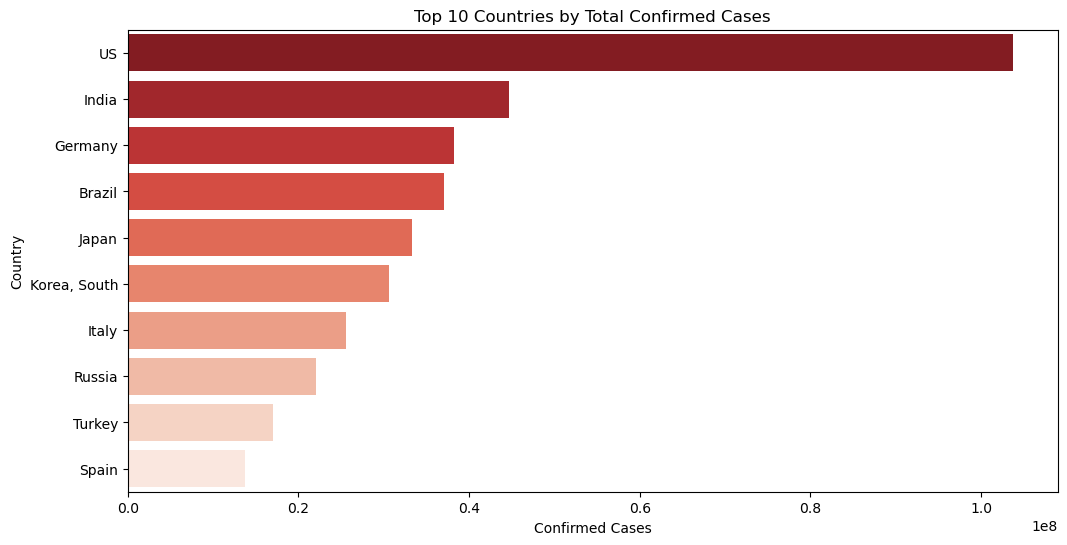

In [248]:
latest_data = master_df.sort_values('Date').groupby('Country/Region').tail(1).copy()
latest_data = latest_data.dropna(subset=['Population'])
latest_data.head()
top_cases = latest_data.nlargest(10, 'Cases_confirmed')

plt.figure(figsize=(12,6))
sns.barplot(data=top_cases, x='Cases_confirmed', y='Country/Region', palette='Reds_r')
plt.title('Top 10 Countries by Total Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.show()


Top 10 Countries by death

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\2488548311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_deaths, x='Cases_deaths', y='Country/Region', palette='dark:red')


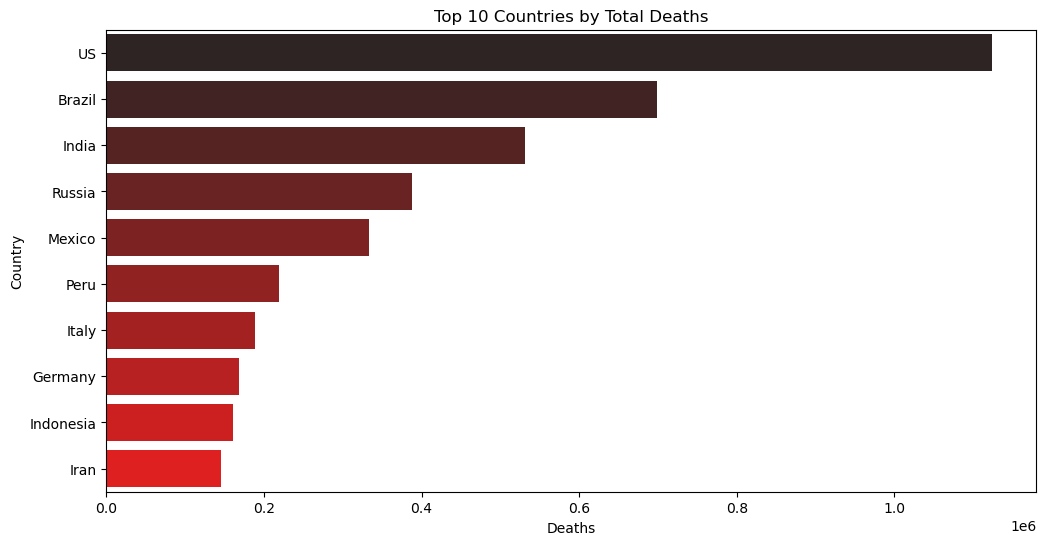

In [249]:
top_deaths = latest_data.nlargest(10, 'Cases_deaths')

plt.figure(figsize=(12,6))
sns.barplot(data=top_deaths, x='Cases_deaths', y='Country/Region', palette='dark:red')
plt.title('Top 10 Countries by Total Deaths')
plt.xlabel('Deaths')
plt.ylabel('Country')
plt.show()


Top 10 Countries by cases per 100k

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\3716739900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_risk, x='cases_per_100k', y='Country/Region', palette='Oranges_r')


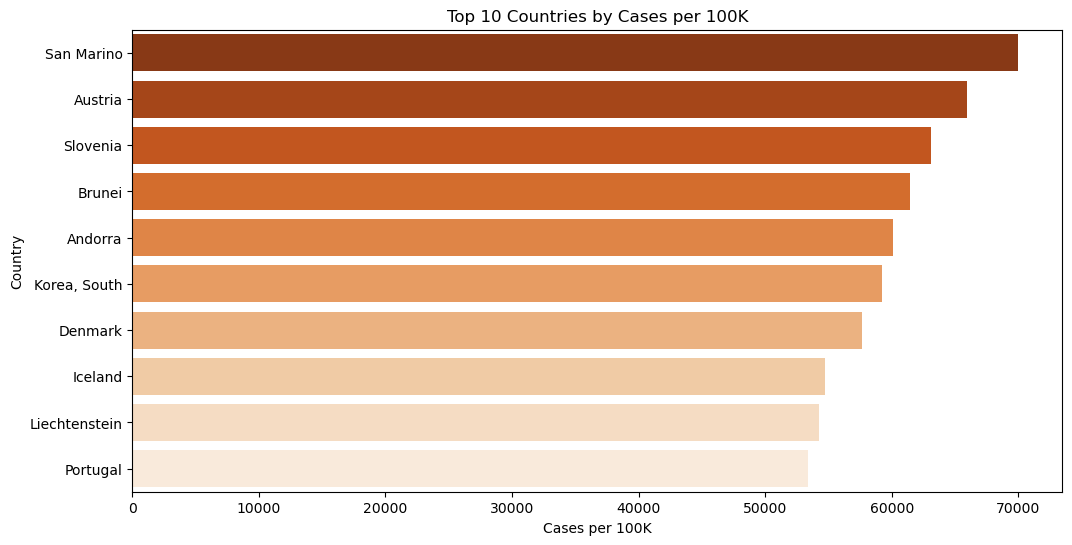

In [250]:
top_risk = latest_data.nlargest(10, 'cases_per_100k')

plt.figure(figsize=(12,6))
sns.barplot(data=top_risk, x='cases_per_100k', y='Country/Region', palette='Oranges_r')
plt.title('Top 10 Countries by Cases per 100K')
plt.xlabel('Cases per 100K')
plt.ylabel('Country')
plt.show()


Risk Category Count

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\4221821861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=latest_data, x='Risk', order=['Low','Medium','High','Critical'], palette='YlOrRd')


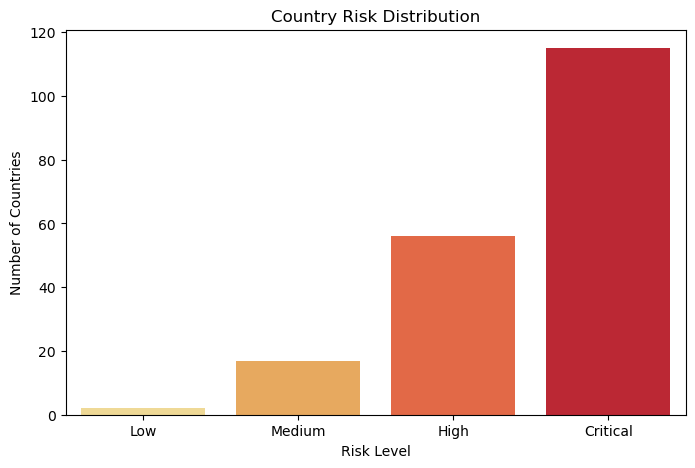

In [251]:
plt.figure(figsize=(8,5))
sns.countplot(data=latest_data, x='Risk', order=['Low','Medium','High','Critical'], palette='YlOrRd')
plt.title('Country Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Countries')
plt.show()


Worldwide daily case trend

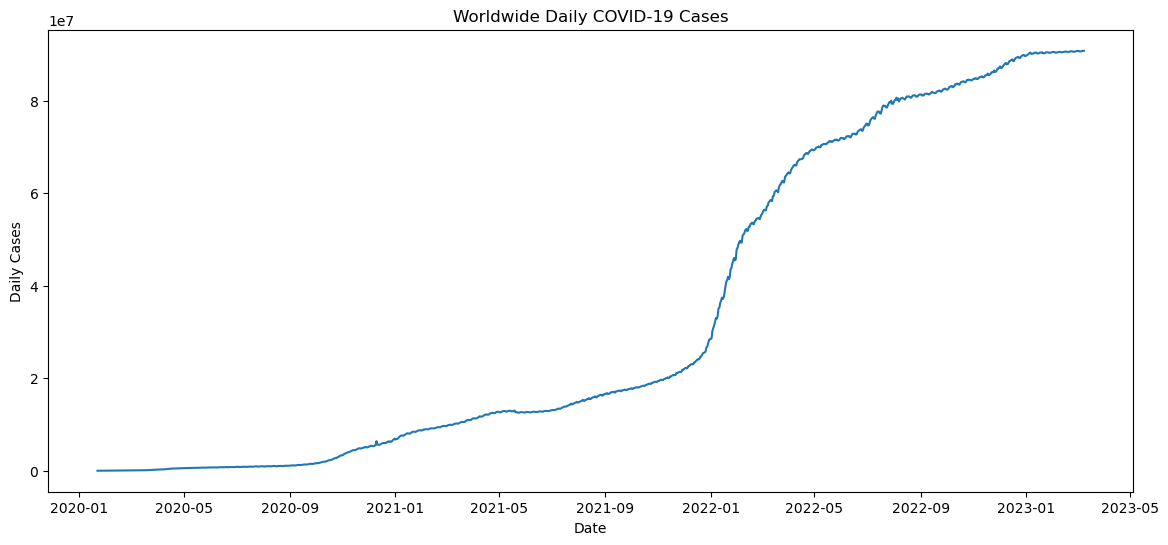

In [252]:
global_daily = master_df.groupby('Date')['Daily Cases'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data=global_daily, x='Date', y='Daily Cases')
plt.title('Worldwide Daily COVID-19 Cases')
plt.xlabel('Date')
plt.ylabel('Daily Cases')
plt.show()


Worldwide 7DMA

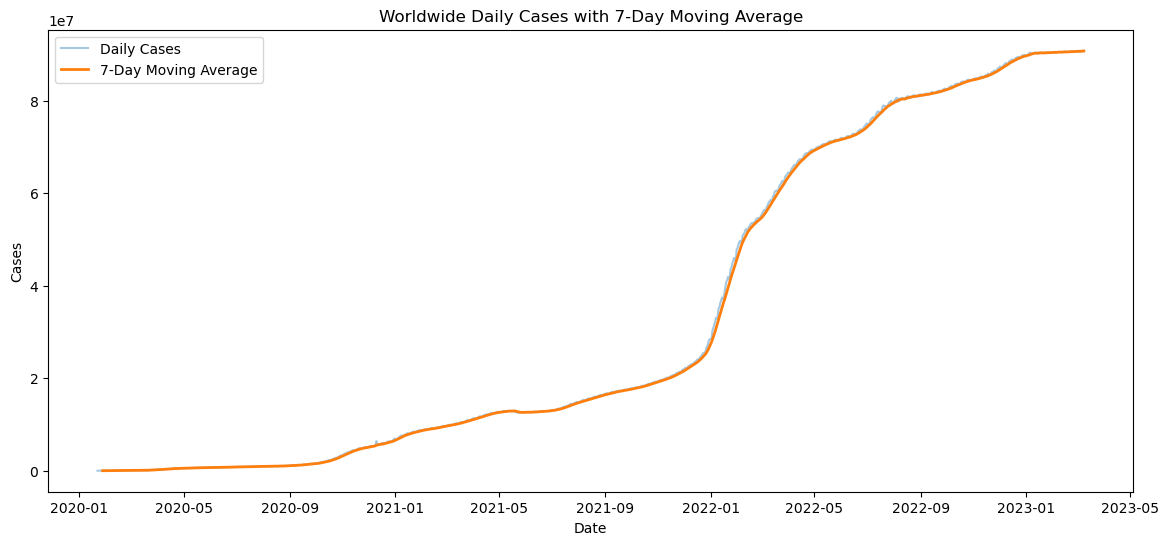

In [253]:
global_daily['7DMA'] = global_daily['Daily Cases'].rolling(7).mean()

plt.figure(figsize=(14,6))
sns.lineplot(data=global_daily, x='Date', y='Daily Cases', label='Daily Cases', alpha=0.4)
sns.lineplot(data=global_daily, x='Date', y='7DMA', label='7-Day Moving Average', linewidth=2)
plt.title('Worldwide Daily Cases with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()


Trend Comaparison for top 5 affected companies

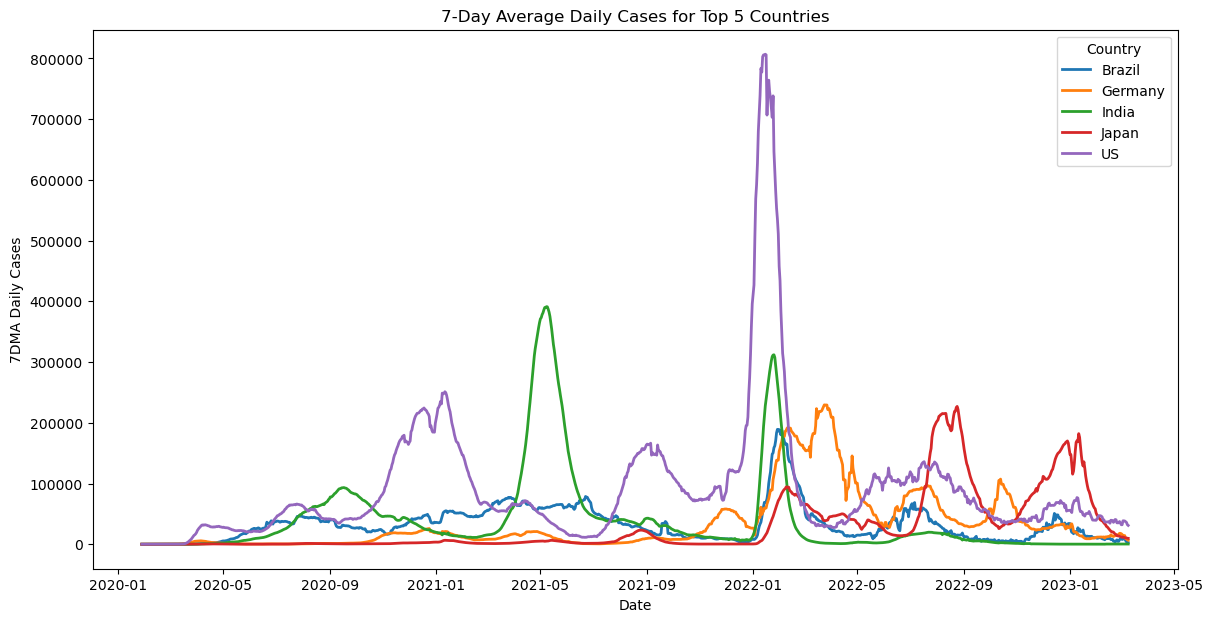

In [254]:
top5 = latest_data.nlargest(5, 'Cases_confirmed')['Country/Region']

top5_trend = master_df[master_df['Country/Region'].isin(top5)]

plt.figure(figsize=(14,7))
sns.lineplot(data=top5_trend, x='Date', y='7DMA', hue='Country/Region', linewidth=2)
plt.title('7-Day Average Daily Cases for Top 5 Countries')
plt.xlabel('Date')
plt.ylabel('7DMA Daily Cases')
plt.legend(title='Country')
plt.show()


Death vs confirmed

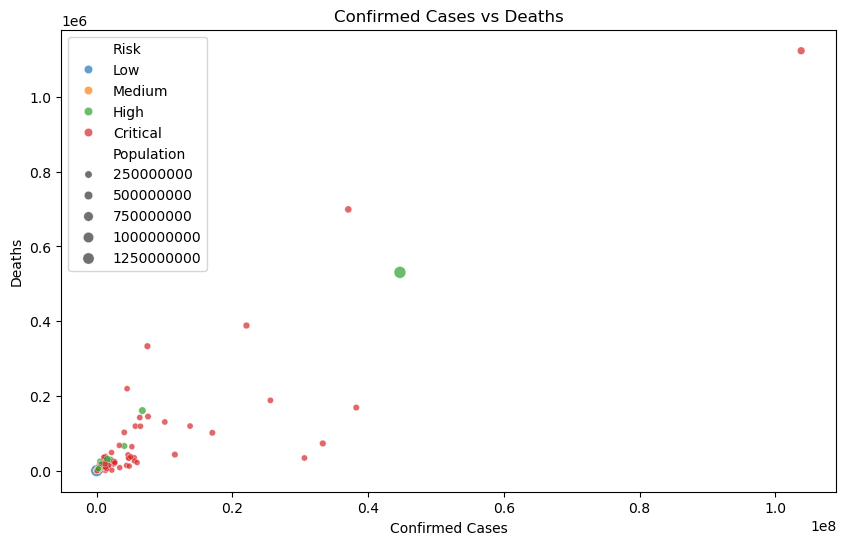

In [255]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=latest_data,
    x='Cases_confirmed',
    y='Cases_deaths',
    size='Population',
    hue='Risk',
    alpha=0.7
)
plt.title('Confirmed Cases vs Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.show()


Recovery Rate

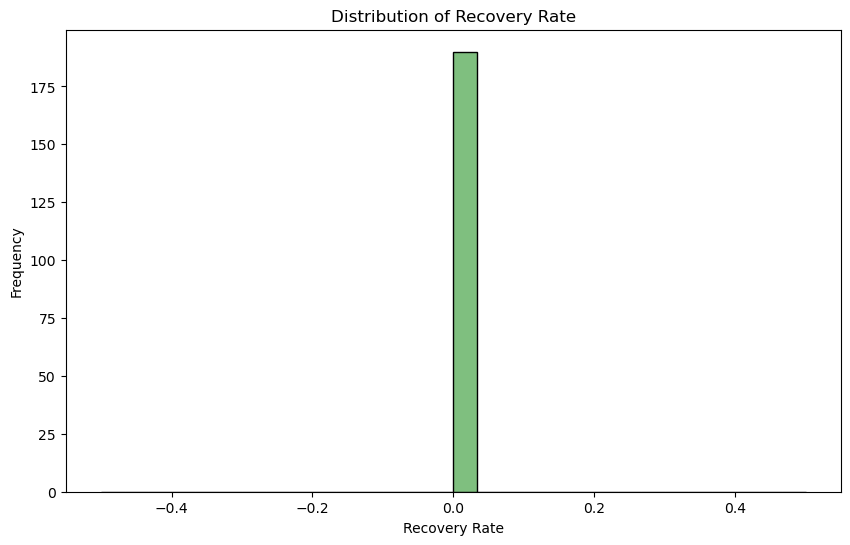

In [256]:
plt.figure(figsize=(10,6))
sns.histplot(latest_data['Recovery Rate'].dropna(), bins=30, kde=True, color='green')
plt.title('Distribution of Recovery Rate')
plt.xlabel('Recovery Rate')
plt.ylabel('Frequency')
plt.show()


Wave Peak

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\3305437787.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_summary, x='7DMA', y='Country/Region', palette='Blues_r')


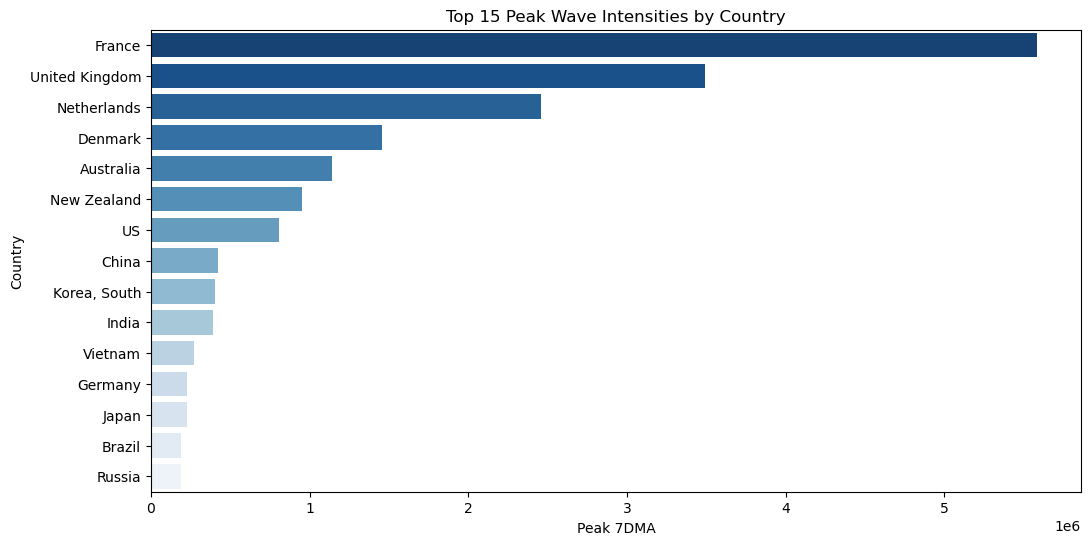

In [257]:
peak_summary = peaks[['Country/Region', 'Date', '7DMA']].sort_values('7DMA', ascending=False).head(15)

plt.figure(figsize=(12,6))
sns.barplot(data=peak_summary, x='7DMA', y='Country/Region', palette='Blues_r')
plt.title('Top 15 Peak Wave Intensities by Country')
plt.xlabel('Peak 7DMA')
plt.ylabel('Country')
plt.show()


Countries in Worse trend

C:\Users\shubh\AppData\Local\Temp\ipykernel_14836\2804747861.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_worsening, x='Trend Change', y='Country/Region', palette='rocket')


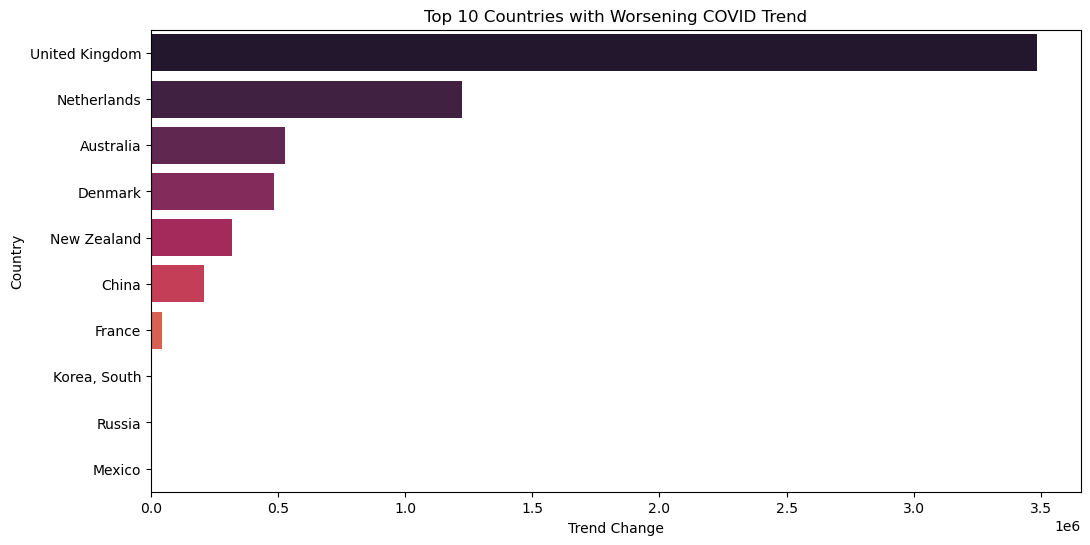

In [258]:
top_worsening = worsening.head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_worsening, x='Trend Change', y='Country/Region', palette='rocket')
plt.title('Top 10 Countries with Worsening COVID Trend')
plt.xlabel('Trend Change')
plt.ylabel('Country')
plt.show()


Matrix

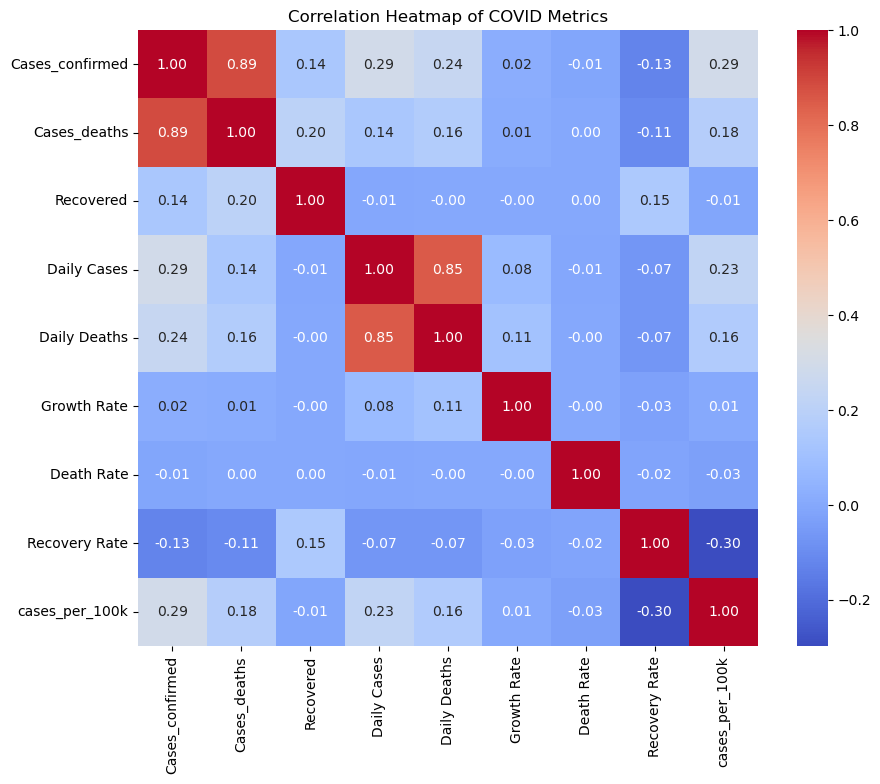

In [259]:
corr_cols = ['Cases_confirmed', 'Cases_deaths', 'Recovered', 'Daily Cases',
             'Daily Deaths', 'Growth Rate', 'Death Rate', 'Recovery Rate',
             'cases_per_100k']

corr = master_df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of COVID Metrics')
plt.show()


In [260]:
master_df.to_csv('covid_master_df.csv', index=False)
latest_data.to_csv('covid_latest_snapshot.csv', index=False)
worsening.to_csv('covid_worsening_trend.csv')
peaks.to_csv('covid_peaks.csv', index=False)
